# 07 — Predicción del ticket medio diario (notebook definitivo)

## Objetivo

Predecir el **ticket medio diario** (facturación / nº de tickets) del restaurante.

**Fuentes de datos**:
- `data/silver/snapshots/tickets_silver.parquet` — de aquí se reconstruye la serie diaria
  (facturación total, nº de tickets, ticket medio, ticket mediano).
  Se ha comprobado que esta reconstrucción coincide al céntimo con `data/gold/tabla_maestra_diaria.parquet`.
- `data/gold/tabla_maestra_diaria.parquet` — se usa solo para tomar prestadas las columnas de
  **contexto** que ya trae integradas (festivos, eventos, meteorología), sin duplicar ese trabajo.
- `data/silver/snapshots/reservas_silver.parquet` — para construir reservas ya confirmadas con
  antelación (sin fuga de información), igual que en el notebook de facturación.

**Qué se compara**: 9 modelos de regresión (4 lineales + 2 bagging + 3 boosting), cada uno ajustado
con `GridSearchCV`/`RandomizedSearchCV` sobre `TimeSeriesSplit`, evaluados con **todas las métricas de
error habituales** (MAE, RMSE, MSE, MAPE, sMAPE, R², error absoluto mediano, varianza explicada, error
máximo) y comparados contra baselines ingenuos.

**Nota conceptual**: el ticket medio es un *cociente* (facturación / nº de tickets) calculado sobre
pocas decenas de tickets por día. Tiene más ruido "de composición" que la facturación total —una sola
mesa grande puede desplazar la media de un día cualquiera—, así que es razonable esperar un techo de
R² más bajo que en la predicción de facturación. Eso no es un fallo del modelo, es una propiedad del
problema, y lo comprobamos al final con un cálculo explícito de ese ruido de composición.


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, HistGradientBoostingRegressor,
)
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, mean_absolute_percentage_error,
    r2_score, median_absolute_error, explained_variance_score, max_error,
)
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
GOLD_DIR = DATA_DIR / 'gold'
SILVER_SNAP = DATA_DIR / 'silver' / 'snapshots'

RESULTS_DIR = PROJECT_ROOT / 'results' / 'ticket_medio_final'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures' / 'ticket_medio_final'
MODELS_DIR = PROJECT_ROOT / 'results' / 'models'
for p in (RESULTS_DIR, FIGURES_DIR, MODELS_DIR):
    p.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

print('Project root:', PROJECT_ROOT)


Project root: C:\Users\CandelaGB\Desktop\TFM anita\TFM-Hosteleria-AI


## 1. Horizonte de predicción

Igual que en el notebook de facturación: `HORIZON = 1` día, es decir, predecir el ticket medio de
**mañana** con todo lo conocido hasta **hoy**. Todas las variables de historial respetan este corte.

In [2]:
HORIZON = 1
print(f'HORIZON = {HORIZON} día(s) de antelación')


HORIZON = 1 día(s) de antelación


## 2. Serie diaria de tickets desde Silver

Se reconstruye la tabla diaria directamente desde `tickets_silver.parquet`. También se añaden el ticket
**mediano** (más robusto frente a mesas grandes puntuales) y la dispersión intradía del ticket
(`ticket_std`, `ticket_max`), que usaremos más adelante solo como historial desplazado, nunca en
crudo del propio día.

In [3]:
tickets = pd.read_parquet(SILVER_SNAP / 'tickets_silver.parquet')
tickets['fecha'] = pd.to_datetime(tickets['date'])

ticket_diario = (
    tickets
    .groupby('fecha')
    .agg(
        facturacion=('document_total', 'sum'),
        num_tickets=('document_id', 'nunique'),
        ticket_mediano=('document_total', 'median'),
        ticket_std=('document_total', 'std'),
        ticket_max=('document_total', 'max'),
    )
    .reset_index()
    .sort_values('fecha')
    .reset_index(drop=True)
)
ticket_diario['ticket_medio'] = ticket_diario['facturacion'] / ticket_diario['num_tickets']

print('Serie diaria de tickets:', ticket_diario.shape)
print(ticket_diario['fecha'].min().date(), '->', ticket_diario['fecha'].max().date())
display(ticket_diario[['facturacion', 'num_tickets', 'ticket_medio', 'ticket_mediano']].describe().round(2))

df = ticket_diario.copy()


Serie diaria de tickets:

 (242, 7)
2025-10-02 -> 2026-07-09


,facturacion,num_tickets,ticket_medio,ticket_mediano
count,242.00,242.00,242.00,242.00
mean,2799.55,27.72,102.20,83.71
std,1346.66,11.32,33.45,25.79
min,637.90,6.00,42.25,19.90
25%,1746.55,19.00,77.71,67.42
50%,2440.93,25.00,98.04,80.00
75%,3816.29,35.00,117.86,96.07
max,6785.20,58.00,294.03,180.00


## 3. Contexto de Gold (festivos, eventos, meteorología) — sin duplicar trabajo

`data/gold/tabla_maestra_diaria.parquet` ya integra festivos, eventos y meteorología a nivel diario.
En vez de volver a cruzar esas fuentes desde Silver, se importan directamente esas columnas de
contexto (nunca `facturacion`/`num_tickets`/`ticket_medio`, que ya se han calculado en el paso
anterior desde Silver, como pide el enunciado).

In [4]:
gold = pd.read_parquet(GOLD_DIR / 'tabla_maestra_diaria.parquet')
gold['fecha'] = pd.to_datetime(gold['fecha'])

contexto_cols = [
    'fecha', 'es_festivo', 'festivo_nombre',
    'tiene_evento', 'intensidad_evento', 'impacto_evento', 'direccion_evento',
    'categoria_evento', 'cat_evento',
    'temperature_max', 'temperature_min', 'temperature_mean',
    'precipitation_mm', 'precipitation_hours', 'wind_speed_max', 'sunshine_duration_h',
]

df = df.merge(gold[contexto_cols], on='fecha', how='left')
print('Filas tras añadir contexto de Gold:', df.shape)


Filas tras añadir contexto de Gold: (242, 22)


## 4. Reservas confirmadas con antelación (Silver, sin fuga de información)

Igual que en el notebook de facturación: reservas que ya existían con al menos `HORIZON` días de
antelación respecto a la fecha de servicio. Es razonable pensar que también influyen en el ticket
medio (más reservas de grupo -> tickets más grandes).

In [5]:
reservas = pd.read_parquet(SILVER_SNAP / 'reservas_silver.parquet')
reservas['reservation_date'] = pd.to_datetime(reservas['reservation_date'])
reservas['created_date'] = pd.to_datetime(reservas['created_date'])

reservas_validas = reservas.dropna(subset=['reservation_date', 'created_date']).copy()
reservas_validas['antelacion_dias'] = (
    reservas_validas['reservation_date'] - reservas_validas['created_date']
).dt.days

conocidas = reservas_validas[reservas_validas['antelacion_dias'] >= HORIZON]

reservas_agg = (
    conocidas
    .groupby('reservation_date')
    .agg(
        reservas_anticipadas=('reference_code', 'count'),
        comensales_anticipados=('people', 'sum'),
        grupos_grandes_anticipados=('es_grupo_grande', 'sum'),
        antelacion_media_dias=('antelacion_dias', 'mean'),
    )
    .reset_index()
    .rename(columns={'reservation_date': 'fecha'})
)

df = df.merge(reservas_agg, on='fecha', how='left')
for c in ['reservas_anticipadas', 'comensales_anticipados', 'grupos_grandes_anticipados']:
    df[c] = df[c].fillna(0)

print(f"Días con reservas anticipadas (>= {HORIZON}d): {(df['reservas_anticipadas'] > 0).sum()} de {len(df)}")


Días con reservas anticipadas (>= 1d): 238 de 242


## 5. Variables de calendario y meteorología derivadas

Codificación cíclica de fecha, festivo adyacente calculado por fecha real (no por posición de fila,
porque el restaurante cierra la mayoría de los lunes) y variables meteorológicas derivadas.

In [6]:
festivos_silver = pd.read_parquet(SILVER_SNAP / 'festivos_silver.parquet')
festivos_silver['fecha'] = pd.to_datetime(festivos_silver['fecha']).dt.normalize()
fechas_festivas = set(festivos_silver['fecha'])

d = df['fecha']

df['dia_semana'] = d.dt.day_name()
df['num_dia'] = d.dt.dayofweek
df['mes'] = d.dt.month
df['anio'] = d.dt.year
df['semana_anio'] = d.dt.isocalendar().week.astype(int)
df['trimestre'] = d.dt.quarter
df['dia_anio'] = d.dt.dayofyear

df['sin_dia_anio'] = np.sin(2 * np.pi * df['dia_anio'] / 365.25)
df['cos_dia_anio'] = np.cos(2 * np.pi * df['dia_anio'] / 365.25)
df['sin_dia_semana'] = np.sin(2 * np.pi * df['num_dia'] / 7)
df['cos_dia_semana'] = np.cos(2 * np.pi * df['num_dia'] / 7)

df['es_fin_de_semana'] = df['num_dia'].isin([5, 6]).astype(int)
df['es_lunes'] = (df['num_dia'] == 0).astype(int)

df['festivo_manana'] = (d + pd.Timedelta(days=1)).dt.normalize().isin(fechas_festivas).astype(int)
df['festivo_ayer'] = (d - pd.Timedelta(days=1)).dt.normalize().isin(fechas_festivas).astype(int)
df['es_puente'] = (
    ((d.dt.weekday == 0) & (df['festivo_manana'] == 1)) |
    ((d.dt.weekday == 4) & (df['festivo_ayer'] == 1))
).astype(int)

df['rango_temperatura'] = df['temperature_max'] - df['temperature_min']
df['es_dia_lluvioso'] = (df['precipitation_mm'].fillna(0) > 0).astype(int)
df['es_dia_muy_caluroso'] = (df['temperature_max'] >= 30).astype(int)
df['es_dia_muy_frio'] = (df['temperature_min'] <= 5).astype(int)

print('Variables de calendario y meteorología creadas.')


Variables de calendario y meteorología creadas.

## 6. Historial (lags y medias móviles) — respetando `HORIZON`

El ticket medio es la variable objetivo, así que es lo que más historial recibe (lags + medias
móviles + tendencia). La facturación y el nº de tickets aportan contexto de "cuánto se vendió" con
menos variables, para no inflar la dimensionalidad en un dataset de sólo ~240 días.

In [7]:
def lags_y_rolling(df, col, lags, windows, std_windows=None, prefix=None):
    prefix = prefix or col
    base = df[col].shift(HORIZON)
    for lag in lags:
        df[f'{prefix}_{lag}d_antes'] = df[col].shift(HORIZON + lag - 1)
    for w in windows:
        df[f'{prefix}_media_{w}d'] = base.rolling(w, min_periods=max(2, w // 3)).mean()
    for w in (std_windows or []):
        df[f'{prefix}_std_{w}d'] = base.rolling(w, min_periods=max(2, w // 3)).std()
    return df

df = lags_y_rolling(df, 'ticket_medio', lags=[1, 3, 7, 14, 21, 28], windows=[3, 7, 14, 28], std_windows=[7, 28])
df['ticket_medio_tendencia_7_28'] = df['ticket_medio_media_7d'] - df['ticket_medio_media_28d']

df = lags_y_rolling(df, 'facturacion', lags=[1, 7, 14], windows=[7])
df = lags_y_rolling(df, 'num_tickets', lags=[1, 7, 14], windows=[7])

df['ticket_mediano_1d_antes'] = df['ticket_mediano'].shift(HORIZON)

print('Variables de historial creadas.')


Variables de historial creadas.


## 7. Selección de variables y control estricto de leakage

Se excluyen el objetivo (`ticket_medio`) y todas las variables que son resultado del propio día:
`facturacion`, `num_tickets`, `ticket_mediano`, `ticket_std`, `ticket_max` (todas ellas solo se
conocen al cerrar el día). Todo lo demás —calendario, meteorología, festivos/eventos, reservas
anticipadas e historial ya desplazado— se conoce antes de que empiece el día objetivo.

In [8]:
target = 'ticket_medio'

leakage_cols = ['ticket_medio', 'facturacion', 'num_tickets', 'ticket_mediano', 'ticket_std', 'ticket_max']
id_cols = ['fecha']

feature_cols = [c for c in df.columns if c not in leakage_cols + id_cols]

X = df[feature_cols].copy()
y = df[target].copy()
fechas = df['fecha'].copy()

print(f'Variables utilizadas ({len(feature_cols)}):')
for c in feature_cols:
    print(' -', c)


Variables utilizadas (61):
 - es_festivo
 - festivo_nombre
 - tiene_evento
 - intensidad_evento
 - impacto_evento
 - direccion_evento
 - categoria_evento
 - cat_evento
 - temperature_max
 - temperature_min
 - temperature_mean
 - precipitation_mm
 - precipitation_hours
 - wind_speed_max
 - sunshine_duration_h
 - reservas_anticipadas
 - comensales_anticipados
 - grupos_grandes_anticipados
 - antelacion_media_dias
 - dia_semana
 - num_dia
 - mes
 - anio
 - semana_anio
 - trimestre
 - dia_anio
 - sin_dia_anio
 - cos_dia_anio
 - sin_dia_semana
 - cos_dia_semana
 - es_fin_de_semana
 - es_lunes
 - festivo_manana
 - festivo_ayer
 - es_puente
 - rango_temperatura
 - es_dia_lluvioso
 - es_dia_muy_caluroso
 - es_dia_muy_frio
 - ticket_medio_1d_antes
 - ticket_medio_3d_antes
 - ticket_medio_7d_antes
 - ticket_medio_14d_antes
 - ticket_medio_21d_antes
 - ticket_medio_28d_antes
 - ticket_medio_media_3d
 - ticket_medio_media_7d
 - ticket_medio_media_14d
 - ticket_medio_media_28d
 - ticket_medio_std_7

## 8. Filas utilizables

In [9]:
before = len(X)
mask = X['ticket_medio_1d_antes'].notna()

X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)
fechas = fechas.loc[mask].reset_index(drop=True)
df_model = df.loc[mask].reset_index(drop=True)

print(f'Filas descartadas por falta de histórico mínimo: {before - len(X)}')
print(f'Filas utilizables: {len(X)}')
display(X.isna().sum().sort_values(ascending=False).head(10).to_frame('nulos'))


Filas descartadas por falta de histórico mínimo: 1
Filas utilizables: 241


,nulos
ticket_medio_28d_antes,27
ticket_medio_21d_antes,20
ticket_medio_14d_antes,13
num_tickets_14d_antes,13
facturacion_14d_antes,13
ticket_medio_tendencia_7_28,8
ticket_medio_std_28d,8
ticket_medio_media_28d,8
num_tickets_7d_antes,6
facturacion_7d_antes,6


## 9. Train / test cronológico (80% / 20%)

In [10]:
split = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split].copy(), X.iloc[split:].copy()
y_train, y_test = y.iloc[:split].copy(), y.iloc[split:].copy()
fechas_train, fechas_test = fechas.iloc[:split], fechas.iloc[split:]

print('TRAIN:', fechas_train.min().date(), '->', fechas_train.max().date(), f'({len(X_train)} días)')
print('TEST :', fechas_test.min().date(), '->', fechas_test.max().date(), f'({len(X_test)} días)')


TRAIN:

 2025-10-03 -> 2026-05-13 (192 días)
TEST : 2026-05-14 -> 2026-07-09 (49 días)


## 10. Preprocesamiento

In [11]:
categorical_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

numeric_linear = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

numeric_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

preprocessor_linear = ColumnTransformer([
    ('num', numeric_linear, numeric_cols),
    ('cat', categorical_pipe, categorical_cols),
])

preprocessor_tree = ColumnTransformer([
    ('num', numeric_tree, numeric_cols),
    ('cat', categorical_pipe, categorical_cols),
])

print(f'Numéricas: {len(numeric_cols)} | Categóricas: {len(categorical_cols)}')


Numéricas: 55 | Categóricas: 6


## 11. Nueve modelos + búsqueda de hiperparámetros

4 lineales (LinearRegression sin regularizar como referencia, Ridge, Lasso, ElasticNet) + 2 de
bagging (Random Forest, Extra Trees) + 3 de boosting (Gradient Boosting, HistGradientBoosting,
XGBoost). Cada uno se ajusta con `GridSearchCV` (espacios pequeños, búsqueda exhaustiva) o
`RandomizedSearchCV` (espacios grandes) usando **`TimeSeriesSplit`** — nunca folds aleatorios.

In [12]:
tscv_search = TimeSeriesSplit(n_splits=5)

base_estimators = {
    'Linear Regression': (LinearRegression(), preprocessor_linear),
    'Ridge': (Ridge(random_state=RANDOM_STATE), preprocessor_linear),
    'Lasso': (Lasso(random_state=RANDOM_STATE, max_iter=20000), preprocessor_linear),
    'ElasticNet': (ElasticNet(random_state=RANDOM_STATE, max_iter=20000), preprocessor_linear),
    'Random Forest': (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1), preprocessor_tree),
    'Extra Trees': (ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=1), preprocessor_tree),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=RANDOM_STATE), preprocessor_tree),
    'HistGradientBoosting': (HistGradientBoostingRegressor(random_state=RANDOM_STATE), preprocessor_tree),
    'XGBoost': (XGBRegressor(random_state=RANDOM_STATE, n_jobs=1, objective='reg:squarederror'), preprocessor_tree),
}

param_grids = {
    'Linear Regression': {},
    'Ridge': {'model__alpha': [0.1, 0.3, 1, 3, 10, 30, 100, 300]},
    'Lasso': {'model__alpha': [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3]},
    'ElasticNet': {
        'model__alpha': [0.001, 0.01, 0.1, 1, 10],
        'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
    },
    'Random Forest': {
        'model__n_estimators': [200, 400, 600],
        'model__max_depth': [None, 4, 6, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': [0.5, 0.7, 1.0],
    },
    'Extra Trees': {
        'model__n_estimators': [200, 400, 600],
        'model__max_depth': [None, 4, 6, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': [0.5, 0.7, 1.0],
    },
    'Gradient Boosting': {
        'model__n_estimators': [100, 200, 400],
        'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
        'model__max_depth': [2, 3, 4],
        'model__min_samples_leaf': [1, 2, 4],
        'model__subsample': [0.7, 0.85, 1.0],
    },
    'HistGradientBoosting': {
        'model__max_iter': [100, 200, 300],
        'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
        'model__max_leaf_nodes': [7, 15, 31],
        'model__l2_regularization': [0.0, 0.5, 1.0, 2.0],
        'model__max_depth': [None, 3, 5],
    },
    'XGBoost': {
        'model__n_estimators': [200, 400, 600],
        'model__max_depth': [2, 3, 4, 6],
        'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
        'model__subsample': [0.6, 0.8, 1.0],
        'model__colsample_bytree': [0.6, 0.8, 1.0],
        'model__reg_alpha': [0, 0.1, 0.5],
        'model__reg_lambda': [1, 2, 5],
    },
}

exhaustive_models = {'Linear Regression', 'Ridge', 'Lasso', 'ElasticNet'}
N_ITER_RANDOM = 25

best_estimators = {}
search_summary = []

for name, (estimator, preprocessor) in base_estimators.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', estimator)])
    grid = param_grids[name]

    if name == 'Linear Regression':
        pipe.fit(X_train, y_train)
        best_estimators[name] = pipe
        cv_scores = []
        for tr_idx, va_idx in tscv_search.split(X_train):
            pipe_fold = Pipeline([('preprocessor', preprocessor_linear), ('model', LinearRegression())])
            pipe_fold.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
            pred_fold = pipe_fold.predict(X_train.iloc[va_idx])
            cv_scores.append(mean_absolute_error(y_train.iloc[va_idx], pred_fold))
        best_mae_cv = np.mean(cv_scores)
        best_params = {}
    elif name in exhaustive_models:
        search = GridSearchCV(pipe, grid, cv=tscv_search, scoring='neg_mean_absolute_error', n_jobs=-1)
        search.fit(X_train, y_train)
        best_estimators[name] = search.best_estimator_
        best_mae_cv = -search.best_score_
        best_params = search.best_params_
    else:
        search = RandomizedSearchCV(
            pipe, grid, n_iter=N_ITER_RANDOM, cv=tscv_search,
            scoring='neg_mean_absolute_error', random_state=RANDOM_STATE, n_jobs=-1,
        )
        search.fit(X_train, y_train)
        best_estimators[name] = search.best_estimator_
        best_mae_cv = -search.best_score_
        best_params = search.best_params_

    search_summary.append({'modelo': name, 'MAE_CV_busqueda': best_mae_cv, 'mejores_parametros': str(best_params)})
    print(f'{name:<20} MAE_CV = {best_mae_cv:7.3f} €   params: {best_params}')

search_summary_df = pd.DataFrame(search_summary).sort_values('MAE_CV_busqueda').reset_index(drop=True)


Linear Regression    MAE_CV = 179.091 €   params: {}


Ridge                MAE_CV =  22.435 €   params: {'model__alpha': 300}


Lasso                MAE_CV =  24.566 €   params: {'model__alpha': 3}


ElasticNet           MAE_CV =  22.902 €   params: {'model__alpha': 10, 'model__l1_ratio': 0.3}


Random Forest        MAE_CV =  18.031 €   params: {'model__n_estimators': 600, 'model__min_samples_leaf': 2, 'model__max_features': 1.0, 'model__max_depth': 6}


Extra Trees          MAE_CV =  18.761 €   params: {'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}


Gradient Boosting    MAE_CV =  18.343 €   params: {'model__subsample': 0.7, 'model__n_estimators': 100, 'model__min_samples_leaf': 1, 'model__max_depth': 3, 'model__learning_rate': 0.03}


HistGradientBoosting MAE_CV =  19.824 €   params: {'model__max_leaf_nodes': 15, 'model__max_iter': 100, 'model__max_depth': 5, 'model__learning_rate': 0.03, 'model__l2_regularization': 0.5}


XGBoost              MAE_CV =  18.497 €   params: {'model__subsample': 0.8, 'model__reg_lambda': 2, 'model__reg_alpha': 0.1, 'model__n_estimators': 400, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.6}


## 12. Resultado de la búsqueda de hiperparámetros

In [13]:
display(search_summary_df)

,modelo,MAE_CV_busqueda,mejores_parametros
0,Random Forest,18.030676,"{'model__n_estimators': 600, 'model__min_sampl..."
1,Gradient Boosting,18.343169,"{'model__subsample': 0.7, 'model__n_estimators..."
2,XGBoost,18.497057,"{'model__subsample': 0.8, 'model__reg_lambda':..."
3,Extra Trees,18.760795,"{'model__n_estimators': 200, 'model__min_sampl..."
4,HistGradientBoosting,19.824031,"{'model__max_leaf_nodes': 15, 'model__max_iter..."
5,Ridge,22.435258,{'model__alpha': 300}
6,ElasticNet,22.901832,"{'model__alpha': 10, 'model__l1_ratio': 0.3}"
7,Lasso,24.566481,{'model__alpha': 3}
8,Linear Regression,179.091435,{}


## 13. Validación cruzada temporal fold a fold (modelos ya afinados)

In [14]:
def smape(y_true, y_pred):
    denom = np.abs(y_true) + np.abs(y_pred)
    m = denom != 0
    return np.mean(2 * np.abs(y_pred[m] - y_true[m]) / denom[m]) * 100

tscv = TimeSeriesSplit(n_splits=5)
fold_rows = []

for name, pipe in best_estimators.items():
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train), start=1):
        pipe.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        pred = pipe.predict(X_train.iloc[va_idx])
        fold_rows.append({
            'modelo': name, 'fold': fold,
            'fecha_inicio_val': fechas_train.iloc[va_idx[0]],
            'fecha_fin_val': fechas_train.iloc[va_idx[-1]],
            'MAE': mean_absolute_error(y_train.iloc[va_idx], pred),
            'RMSE': mean_squared_error(y_train.iloc[va_idx], pred) ** 0.5,
            'R2': r2_score(y_train.iloc[va_idx], pred),
            'sMAPE_%': smape(y_train.iloc[va_idx].values, pred),
        })

fold_results = pd.DataFrame(fold_rows)

cv_summary = (
    fold_results.groupby('modelo')
    .agg(MAE_mean=('MAE', 'mean'), MAE_std=('MAE', 'std'),
         RMSE_mean=('RMSE', 'mean'), R2_mean=('R2', 'mean'), sMAPE_mean=('sMAPE_%', 'mean'))
    .sort_values('MAE_mean')
)
display(cv_summary)


,MAE_mean,MAE_std,RMSE_mean,R2_mean,sMAPE_mean
modelo,,,,,
Random Forest,18.030676,6.459318,24.829164,0.400843,16.649721
Gradient Boosting,18.343169,7.371588,25.239489,0.381619,16.998865
XGBoost,18.497057,7.753117,25.440241,0.365175,17.084502
Extra Trees,18.760795,8.012264,25.669355,0.346361,17.165801
HistGradientBoosting,19.824031,7.178770,27.394835,0.236466,18.306643
Ridge,22.435258,11.447977,29.539612,0.119675,21.395542
ElasticNet,22.901832,6.597884,30.715288,0.067980,21.451890
Lasso,24.566481,15.039747,31.326383,-0.153738,24.850703
Linear Regression,179.091435,268.868802,221.548363,-65.871190,75.906221


## 14. Entrenamiento final y evaluación en test futuro — todas las métricas de error

MAE, RMSE, MSE, MAPE, sMAPE, R², error absoluto mediano, varianza explicada y error máximo.

In [15]:
def todas_las_metricas(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'MSE': mean_squared_error(y_true, y_pred),
        'MAPE_%': mean_absolute_percentage_error(y_true, y_pred) * 100,
        'sMAPE_%': smape(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'MedAE': median_absolute_error(y_true, y_pred),
        'Varianza_explicada': explained_variance_score(y_true, y_pred),
        'Error_maximo': max_error(y_true, y_pred),
    }

test_results = []
test_predictions = {}

for name, pipe in best_estimators.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    test_predictions[name] = pred
    row = {'modelo': name}
    row.update(todas_las_metricas(y_test, pred))
    test_results.append(row)

test_results_df = pd.DataFrame(test_results).sort_values('MAE').reset_index(drop=True)
display(test_results_df.round(3))


,modelo,MAE,RMSE,MSE,MAPE_%,sMAPE_%,R2,MedAE,Varianza_explicada,Error_maximo
0,Ridge,13.849,16.958,287.568,15.611,14.816,0.540,11.645,0.559,40.943
1,Lasso,15.417,17.996,323.854,17.370,16.354,0.482,14.035,0.520,40.986
2,Extra Trees,15.564,18.419,339.270,18.211,16.336,0.457,15.294,0.639,45.467
3,Random Forest,17.648,20.187,407.518,19.932,18.078,0.348,18.377,0.544,35.653
4,ElasticNet,18.240,21.659,469.117,22.315,19.737,0.250,16.045,0.374,45.957
5,Gradient Boosting,18.376,21.306,453.949,20.749,18.755,0.274,17.810,0.455,45.571
6,HistGradientBoosting,19.105,21.651,468.756,22.472,19.875,0.250,19.684,0.526,43.091
7,XGBoost,19.603,22.994,528.726,22.373,19.724,0.154,18.672,0.481,47.128
8,Linear Regression,42.426,48.864,2387.692,50.580,37.923,-2.819,40.778,-0.513,107.461


## 15. Comparación con baselines ingenuos

In [16]:
ticket_por_fecha = df.set_index('fecha')['ticket_medio']

baseline_naive = df_model['ticket_medio_1d_antes'].iloc[split:].values
mask_b = ~np.isnan(baseline_naive)

fechas_semana_previa = fechas_test - pd.Timedelta(days=7)
baseline_seasonal = fechas_semana_previa.map(ticket_por_fecha).values
mask_s = ~np.isnan(baseline_seasonal)

baseline_media = np.full(len(y_test), y_train.mean())

baselines_df = pd.DataFrame([
    {'modelo': 'Baseline (día anterior)', **todas_las_metricas(y_test[mask_b], baseline_naive[mask_b])},
    {'modelo': 'Baseline (semana anterior)', **todas_las_metricas(y_test[mask_s], baseline_seasonal[mask_s])},
    {'modelo': 'Baseline (media histórica)', **todas_las_metricas(y_test, baseline_media)},
])

comparison_df = pd.concat([test_results_df, baselines_df], ignore_index=True).sort_values('MAE').reset_index(drop=True)
display(comparison_df.round(3))


,modelo,MAE,RMSE,MSE,MAPE_%,sMAPE_%,R2,MedAE,Varianza_explicada,Error_maximo
0,Ridge,13.849,16.958,287.568,15.611,14.816,0.540,11.645,0.559,40.943
1,Baseline (semana anterior),14.963,19.625,385.138,17.047,15.949,0.405,10.220,0.415,51.718
2,Lasso,15.417,17.996,323.854,17.370,16.354,0.482,14.035,0.520,40.986
3,Extra Trees,15.564,18.419,339.270,18.211,16.336,0.457,15.294,0.639,45.467
4,Random Forest,17.648,20.187,407.518,19.932,18.078,0.348,18.377,0.544,35.653
5,ElasticNet,18.240,21.659,469.117,22.315,19.737,0.250,16.045,0.374,45.957
6,Gradient Boosting,18.376,21.306,453.949,20.749,18.755,0.274,17.810,0.455,45.571
7,HistGradientBoosting,19.105,21.651,468.756,22.472,19.875,0.250,19.684,0.526,43.091
8,XGBoost,19.603,22.994,528.726,22.373,19.724,0.154,18.672,0.481,47.128
9,Baseline (día anterior),23.039,30.494,929.870,26.470,23.813,-0.487,16.611,-0.487,99.641


## 16. Ranking final

In [17]:
ranking = test_results_df.copy()
ranking['rank_MAE'] = ranking['MAE'].rank(method='min')
ranking['rank_RMSE'] = ranking['RMSE'].rank(method='min')
ranking['rank_R2'] = ranking['R2'].rank(method='min', ascending=False)
ranking['score_ranking'] = ranking['rank_MAE'] + ranking['rank_RMSE'] + ranking['rank_R2']
ranking = ranking.sort_values(['score_ranking', 'MAE']).reset_index(drop=True)

best_model_name = ranking.iloc[0]['modelo']
print('Mejor modelo:', best_model_name)
display(ranking[['modelo', 'MAE', 'RMSE', 'R2', 'sMAPE_%', 'score_ranking']])


Mejor modelo: Ridge


,modelo,MAE,RMSE,R2,sMAPE_%,score_ranking
0,Ridge,13.849385,16.957824,0.540078,14.816188,3.0
1,Lasso,15.417007,17.995932,0.482044,16.354011,6.0
2,Extra Trees,15.564075,18.419289,0.457388,16.336498,9.0
3,Random Forest,17.647643,20.187086,0.348235,18.077755,12.0
4,Gradient Boosting,18.375864,21.306068,0.273977,18.754804,16.0
5,ElasticNet,18.239632,21.659102,0.249717,19.737350,19.0
6,HistGradientBoosting,19.104733,21.650784,0.250293,19.874810,19.0
7,XGBoost,19.603487,22.994043,0.154381,19.724105,24.0
8,Linear Regression,42.426332,48.864016,-2.818760,37.922970,27.0


## 17. ¿Supera a los baselines? ¿Y al "techo de ruido" del propio ticket medio?

Además de comparar contra los baselines, calculamos un techo de referencia: el **ruido de
composición** del ticket medio. Si dividiéramos aleatoriamente los tickets de un mismo periodo en
dos mitades, ¿cuánto varía la media entre esas dos mitades por puro azar de qué mesas tocaron cada
día? Ese es aproximadamente el error que ningún modelo, por bueno que sea, puede eliminar.

In [18]:
best_row = test_results_df.loc[test_results_df['modelo'] == best_model_name].iloc[0]

for label in ['día anterior', 'semana anterior', 'media histórica']:
    baseline_mae = baselines_df.loc[baselines_df['modelo'] == f'Baseline ({label})', 'MAE'].iloc[0]
    if best_row['MAE'] < baseline_mae:
        mejora = (baseline_mae - best_row['MAE']) / baseline_mae * 100
        print(f"Frente al baseline de {label}: mejora el MAE en un {mejora:.1f}%.")
    else:
        empeora = (best_row['MAE'] - baseline_mae) / baseline_mae * 100
        print(f"ATENCIÓN: frente al baseline de {label}, el modelo NO mejora (MAE un {empeora:.1f}% peor).")

# Ruido de composición: desviación típica del ticket medio estimada a partir de
# la dispersión intradía de los propios tickets (ticket_std) y el nº de tickets del día.
# Error estándar de la media muestral ~= std_intradia / sqrt(n_tickets)
ruido_composicion = (df_model['ticket_std'].iloc[split:] / np.sqrt(df_model['num_tickets'].iloc[split:])).mean()
print(f"\nRuido de composición estimado (error estándar típico de la media diaria): {ruido_composicion:.2f} €")
print(f"MAE del mejor modelo: {best_row['MAE']:.2f} €")
if best_row['MAE'] <= ruido_composicion * 2:
    print("El modelo se mueve en el orden de magnitud del ruido intrínseco del problema: buena señal,")
    print("difícilmente se puede exigir mucho más sin más información granular intradía.")


Frente al baseline de día anterior: mejora el MAE en un 39.9%.
Frente al baseline de semana anterior: mejora el MAE en un 7.4%.
Frente al baseline de media histórica: mejora el MAE en un 40.2%.

Ruido de composición estimado (error estándar típico de la media diaria): 13.16 €
MAE del mejor modelo: 13.85 €
El modelo se mueve en el orden de magnitud del ruido intrínseco del problema: buena señal,
difícilmente se puede exigir mucho más sin más información granular intradía.


## 18. MAE relativo al ticket medio (interpretación de negocio)

In [19]:
mean_ticket_test = y_test.mean()
relative_mae = best_row['MAE'] / mean_ticket_test * 100

print(f"Ticket medio promedio en test: {mean_ticket_test:.2f} €")
print(f"MAE del mejor modelo ({best_model_name}): {best_row['MAE']:.2f} €")
print(f"MAE relativo: {relative_mae:.2f}%")

if relative_mae < 10:
    print("Interpretación orientativa: MUY BUENO")
elif relative_mae < 20:
    print("Interpretación orientativa: BUENO / RAZONABLE")
elif relative_mae < 30:
    print("Interpretación orientativa: MEJORABLE")
else:
    print("Interpretación orientativa: DÉBIL")


Ticket medio promedio en test: 93.58 €
MAE del mejor modelo (Ridge): 13.85 €
MAE relativo: 14.80%
Interpretación orientativa: BUENO / RAZONABLE


## 19. Gráficos — métricas por modelo

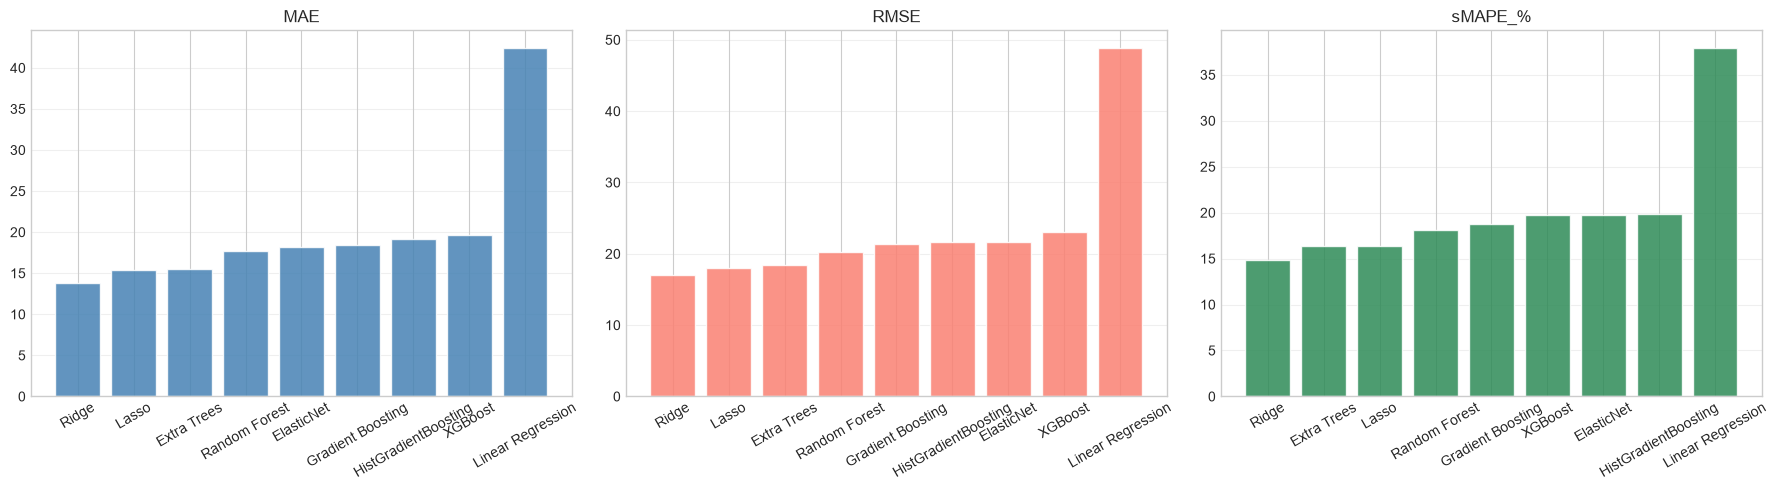

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, color in zip(axes, ['MAE', 'RMSE', 'sMAPE_%'], ['steelblue', 'salmon', 'seagreen']):
    plot_df = test_results_df.sort_values(metric)
    ax.bar(plot_df['modelo'], plot_df[metric], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'metricas_por_modelo.png', dpi=150, bbox_inches='tight')
plt.show()


## 20. Ticket medio real vs. predicciones (test)

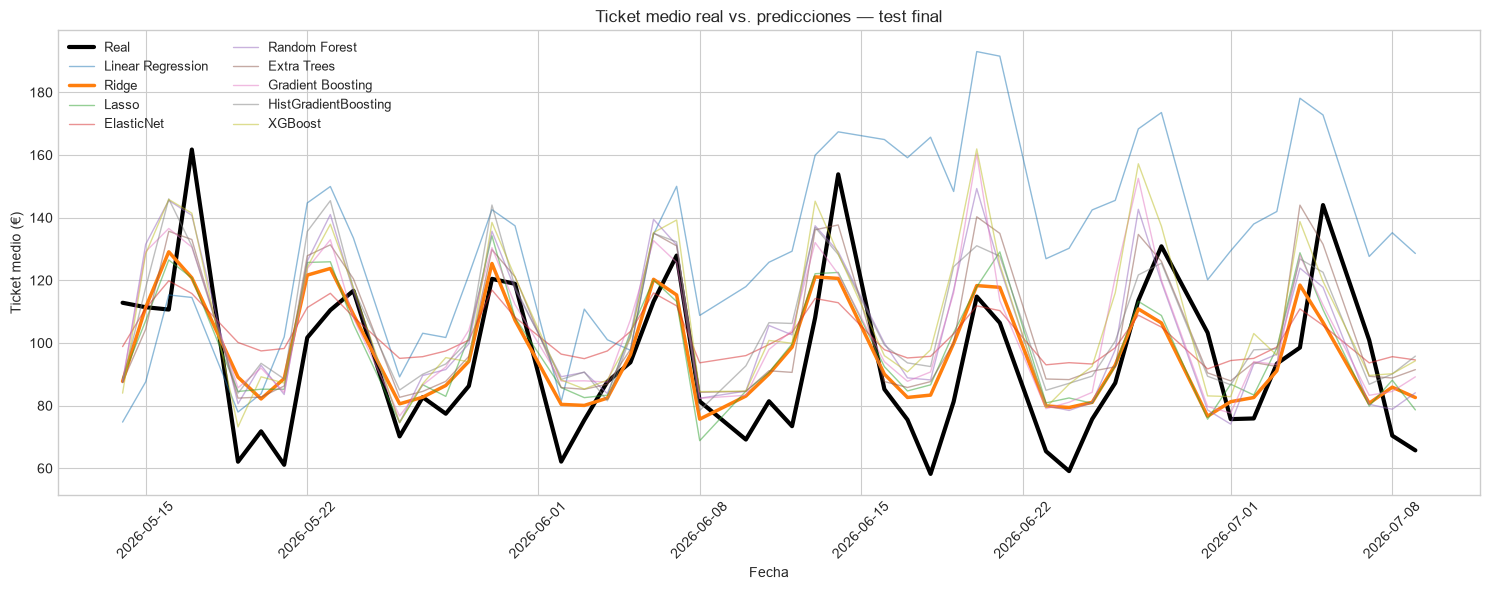

In [21]:
plt.figure(figsize=(15, 6))
plt.plot(fechas_test, y_test.values, label='Real', linewidth=3, color='black')

for name, pred in test_predictions.items():
    lw = 2.5 if name == best_model_name else 1.0
    alpha = 1.0 if name == best_model_name else 0.5
    plt.plot(fechas_test, pred, label=name, linewidth=lw, alpha=alpha)

plt.xlabel('Fecha')
plt.ylabel('Ticket medio (€)')
plt.title('Ticket medio real vs. predicciones — test final')
plt.legend(ncol=2, fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'real_vs_prediccion.png', dpi=150, bbox_inches='tight')
plt.show()


## 21. Análisis de residuos del mejor modelo

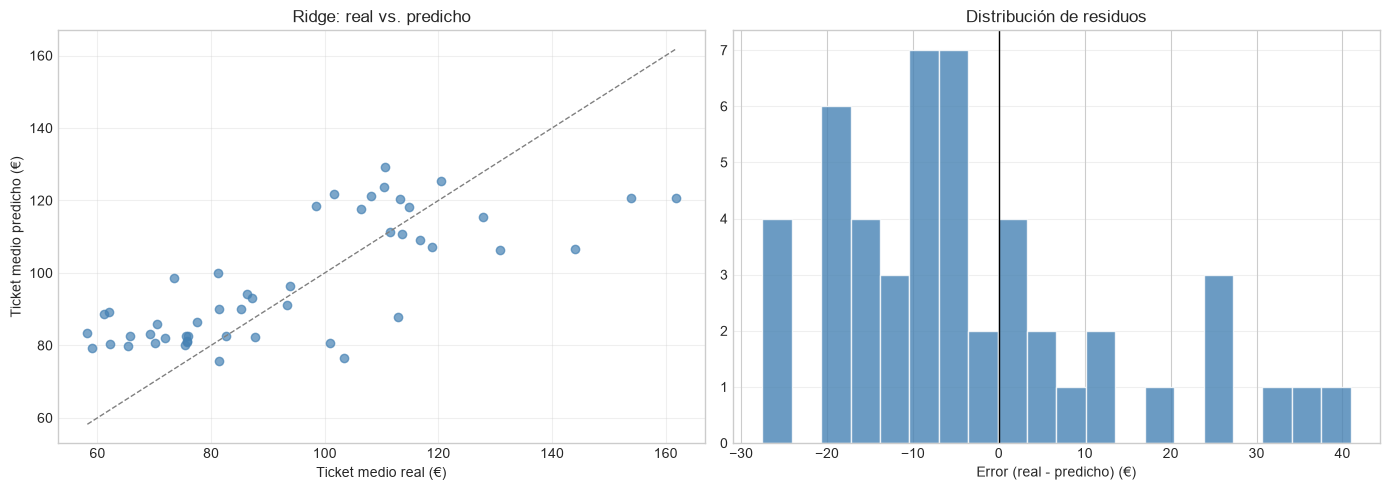

Peores 15 predicciones:


,fecha,ticket_real,ticket_predicho,error,error_abs,error_pct
3,2026-05-17,161.747059,120.804521,40.942538,40.942538,25.312694
45,2026-07-05,144.029167,106.594298,37.434869,37.434869,25.991172
27,2026-06-14,153.834615,120.609380,33.225235,33.225235,21.598023
6,2026-05-21,61.124194,88.659946,-27.535752,27.535752,45.048860
4,2026-05-19,62.106452,89.100460,-26.994009,26.994009,43.464098
40,2026-06-30,103.297826,76.634272,26.663554,26.663554,25.812309
25,2026-06-12,73.452941,98.662554,-25.209613,25.209613,34.320767
30,2026-06-18,58.220588,83.369255,-25.148667,25.148667,43.195487
0,2026-05-14,112.842105,87.762339,25.079766,25.079766,22.225539
39,2026-06-28,130.859375,106.394942,24.464433,24.464433,18.695208


In [22]:
best_pred = test_predictions[best_model_name]

errores = pd.DataFrame({
    'fecha': fechas_test.values,
    'ticket_real': y_test.values,
    'ticket_predicho': best_pred,
})
errores['error'] = errores['ticket_real'] - errores['ticket_predicho']
errores['error_abs'] = errores['error'].abs()
errores['error_pct'] = errores['error_abs'] / errores['ticket_real'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(errores['ticket_real'], errores['ticket_predicho'], alpha=0.7, color='steelblue')
lims = [min(errores['ticket_real'].min(), errores['ticket_predicho'].min()),
        max(errores['ticket_real'].max(), errores['ticket_predicho'].max())]
axes[0].plot(lims, lims, color='grey', linestyle='--', linewidth=1)
axes[0].set_xlabel('Ticket medio real (€)')
axes[0].set_ylabel('Ticket medio predicho (€)')
axes[0].set_title(f'{best_model_name}: real vs. predicho')
axes[0].grid(alpha=0.3)

axes[1].hist(errores['error'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Error (real - predicho) (€)')
axes[1].set_title('Distribución de residuos')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'residuos_mejor_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

print('Peores 15 predicciones:')
display(errores.sort_values('error_abs', ascending=False).head(15))


## 22. Importancia de variables

Coeficientes — Ridge:


,variable,coeficiente
11,num__comensales_anticipados,3.877420
13,num__antelacion_media_dias,3.799536
0,num__es_festivo,2.825028
12,num__grupos_grandes_anticipados,2.807956
14,num__num_dia,2.739704
24,num__es_fin_de_semana,2.101146
22,num__sin_dia_semana,-1.912041
10,num__reservas_anticipadas,1.716303
47,num__facturacion_7d_antes,1.562385
45,num__ticket_medio_tendencia_7_28,1.455415



Importancia por permutación (impacto en MAE al barajar la variable, en €):


,variable,importancia_permutacion,std
20,num_dia,0.918510,0.326323
30,es_fin_de_semana,0.718537,0.267981
28,sin_dia_semana,0.549776,0.248673
53,facturacion_7d_antes,0.321766,0.181931
41,ticket_medio_7d_antes,0.259392,0.100919
19,dia_semana,0.248339,0.064130
51,ticket_medio_tendencia_7_28,0.232724,0.084855
52,facturacion_1d_antes,0.228207,0.135937
39,ticket_medio_1d_antes,0.141209,0.042737
46,ticket_medio_media_7d,0.135068,0.085283


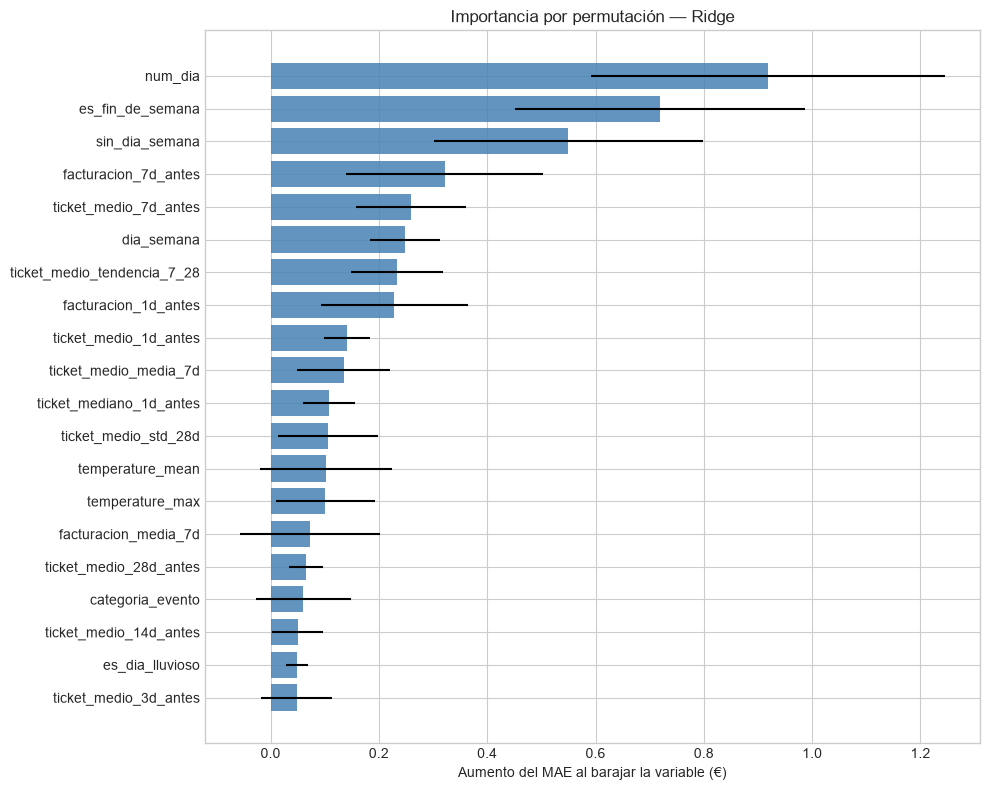

In [23]:
best_pipe = best_estimators[best_model_name]
best_pipe.fit(X_train, y_train)
fitted_model = best_pipe.named_steps['model']
feature_names_out = best_pipe.named_steps['preprocessor'].get_feature_names_out()

if hasattr(fitted_model, 'feature_importances_'):
    native_imp = (
        pd.DataFrame({'variable': feature_names_out, 'importancia': fitted_model.feature_importances_})
        .sort_values('importancia', ascending=False).head(20)
    )
    print(f'Importancia nativa — {best_model_name}:')
    display(native_imp)
elif hasattr(fitted_model, 'coef_'):
    coef_imp = (
        pd.DataFrame({'variable': feature_names_out, 'coeficiente': fitted_model.coef_})
        .assign(abs_coef=lambda d: d['coeficiente'].abs())
        .sort_values('abs_coef', ascending=False).head(20)
        .drop(columns='abs_coef')
    )
    print(f'Coeficientes — {best_model_name}:')
    display(coef_imp)

perm = permutation_importance(
    best_pipe, X_test, y_test, n_repeats=30,
    random_state=RANDOM_STATE, scoring='neg_mean_absolute_error', n_jobs=-1,
)
perm_imp = (
    pd.DataFrame({'variable': X_test.columns, 'importancia_permutacion': perm.importances_mean, 'std': perm.importances_std})
    .sort_values('importancia_permutacion', ascending=False).head(20)
)
print('\nImportancia por permutación (impacto en MAE al barajar la variable, en €):')
display(perm_imp)

plt.figure(figsize=(10, 8))
plot_perm = perm_imp.sort_values('importancia_permutacion')
plt.barh(plot_perm['variable'], plot_perm['importancia_permutacion'], xerr=plot_perm['std'], color='steelblue', alpha=0.85)
plt.xlabel('Aumento del MAE al barajar la variable (€)')
plt.title(f'Importancia por permutación — {best_model_name}')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'importancia_permutacion.png', dpi=150, bbox_inches='tight')
plt.show()


## 23. Guardar resultados y modelo

In [24]:
cv_summary.to_csv(RESULTS_DIR / 'cv_resultados_por_modelo.csv')
fold_results.to_csv(RESULTS_DIR / 'cv_fold_a_fold.csv', index=False)
search_summary_df.to_csv(RESULTS_DIR / 'busqueda_hiperparametros.csv', index=False)
comparison_df.to_csv(RESULTS_DIR / 'test_vs_baselines.csv', index=False)
errores.to_csv(RESULTS_DIR / 'predicciones_mejor_modelo.csv', index=False)
perm_imp.to_csv(RESULTS_DIR / 'importancia_permutacion.csv', index=False)

joblib.dump(best_pipe, MODELS_DIR / 'mejor_modelo_ticket_medio.joblib')

print('Resultados guardados en:', RESULTS_DIR)
print('Modelo guardado en     :', MODELS_DIR / 'mejor_modelo_ticket_medio.joblib')


Resultados guardados en: C:\Users\CandelaGB\Desktop\TFM anita\TFM-Hosteleria-AI\results\ticket_medio_final
Modelo guardado en     : C:\Users\CandelaGB\Desktop\TFM anita\TFM-Hosteleria-AI\results\models\mejor_modelo_ticket_medio.joblib


## 24. Conclusión automática

In [25]:
print('=' * 72)
print('CONCLUSIÓN')
print('=' * 72)
print(f'Horizonte de predicción : {HORIZON} día(s)')
print(f'Mejor modelo (test)     : {best_model_name}')
print(f"MAE                     : {best_row['MAE']:.2f} €")
print(f"RMSE                    : {best_row['RMSE']:.2f} €")
print(f"MAPE                    : {best_row['MAPE_%']:.2f}%")
print(f"sMAPE                   : {best_row['sMAPE_%']:.2f}%")
print(f"R²                      : {best_row['R2']:.4f}")
print(f"Error absoluto mediano  : {best_row['MedAE']:.2f} €")
print(f'MAE relativo            : {relative_mae:.2f}%')
print(f'Ruido de composición    : {ruido_composicion:.2f} € (referencia, no un modelo)')

print('\nLimitaciones a tener en cuenta en el TFM:')
print('- El ticket medio es un cociente calculado sobre pocas decenas de tickets/día: tiene un')
print('  techo de predictibilidad más bajo que la facturación total por construcción del problema.')
print('- Solo se dispone de un ciclo anual completo: no se puede confirmar estacionalidad anual real.')
print('- El dataset es pequeño (~200 días útiles tras construir historial); limita la complejidad')
print('  de modelo que se puede ajustar con garantías.')
print('- Los resultados corresponden a un único restaurante; no se pueden generalizar sin más.')


CONCLUSIÓN
Horizonte de predicción : 1 día(s)
Mejor modelo (test)     : Ridge
MAE                     : 13.85 €
RMSE                    : 16.96 €
MAPE                    : 15.61%
sMAPE                   : 14.82%
R²                      : 0.5401
Error absoluto mediano  : 11.64 €
MAE relativo            : 14.80%
Ruido de composición    : 13.16 € (referencia, no un modelo)

Limitaciones a tener en cuenta en el TFM:
- El ticket medio es un cociente calculado sobre pocas decenas de tickets/día: tiene un
  techo de predictibilidad más bajo que la facturación total por construcción del problema.
- Solo se dispone de un ciclo anual completo: no se puede confirmar estacionalidad anual real.
- El dataset es pequeño (~200 días útiles tras construir historial); limita la complejidad
  de modelo que se puede ajustar con garantías.
- Los resultados corresponden a un único restaurante; no se pueden generalizar sin más.
